In [2]:
import pandas as pd
import simpy
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r"/Users/xiazheng/Desktop/UVA/Courses25-26/S1P2/Stochastic_Simulation/assignment/assignment2/airport.csv"
data = pd.read_csv(file_path)

In [3]:
# Part 1: get arrival rate from data
sept = data[(data["Month"] == "September") & (data["Year"] <= 2019) & (data["Year"] > 2014) ]
sept_mean = (sept["Total Passengers"]).mean() # monthly avg

In [4]:
# Part 2: build a discrete-event simulator
class MG1QueueSimulator:
    def __init__(self, arrival_rate, service_mean, service_stdev, num_passengers, warm_up, num_servers=1, seed=444):
        # define parameters
        self.arrival_rate = arrival_rate
        self.service_mean = service_mean
        self.service_stdev = service_stdev
        self.num_passengers = num_passengers
        self.warm_up = warm_up
        self.num_servers = num_servers
        # random seed 
        self.rng = np.random.default_rng(seed)

        # collect data
        self.wait_times = [] 
        self.served_passengers = [] 

        # generate simpy environment
        self.env = simpy.Environment()
        self.server = simpy.Resource(self.env, capacity=self.num_servers)


    def passenger(self, id):
        arrival_time = self.env.now

        with self.server.request() as req:
            yield req
            start_service = self.env.now

            # collect waiting time only after warm-up
            if len(self.served_passengers) >= self.warm_up:
                self.wait_times.append(start_service - arrival_time)

            # accept service time (normal distribution) only if positive
            while True:
                service_time = self.rng.normal(self.service_mean, self.service_stdev)
                if service_time > 0:
                    break
            yield self.env.timeout(service_time)
            self.served_passengers.append(self.env.now)

    def arrival_process(self):
        for id in range(self.num_passengers):
            self.env.process(self.passenger(id))
            interarrival = self.rng.exponential(1 / self.arrival_rate)
            yield self.env.timeout(interarrival)

    def run(self):
        self.env.process(self.arrival_process())
        self.env.run()

        return np.array(self.wait_times)
    
    def departure_rate(self):
        if len(self.served_passengers) <= self.warm_up:
            return 0
        total_time = self.served_passengers[-1] - self.served_passengers[self.warm_up]
        return (len(self.served_passengers) - self.warm_up) / total_time


In [5]:
# simulation function
def run_simulations(n_runs = 40, **sim_params):
    mean_waits = []
    departure_rates = []
    for r in range(n_runs):
        sim = MG1QueueSimulator(seed = 444 + r, **sim_params)
        waits = sim.run()
        if len(waits) > 0:
            mean_waits.append(waits.mean())
            departure_rates.append(sim.departure_rate())
    return np.array(mean_waits), np.array(departure_rates)


In [6]:
# 2A: validate results of simulator
rho = 0.85
E_B = 1.0           
sigma = 0.25
lambda_test = rho / E_B

In [7]:
# theoretical waiting time
E_S2 = E_B**2 + sigma**2
Wq = (lambda_test * E_S2) / (2*(1-lambda_test*E_B))
print(Wq)

3.010416666666666


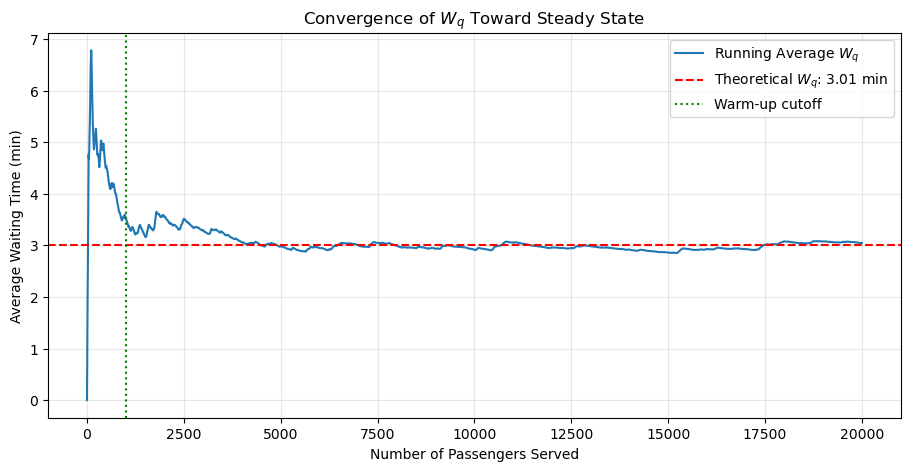

In [8]:
# Check convergence to Wq_theoretical by increasing number of individuals 
sim_convergence = MG1QueueSimulator(lambda_test, E_B, sigma,
                          num_passengers=20000,
                          warm_up=0,              
                          num_servers=1)

waits_convergence = sim_convergence.run() 
running_avg = np.cumsum(waits_convergence) / np.arange(1, len(waits_convergence) + 1) # vectorized cumulative avg
increasing_n = np.arange(1, len(waits_convergence) + 1)

plt.figure(figsize=(11, 5))
plt.plot(increasing_n, running_avg, label='Running Average $W_q$')
plt.axhline(Wq, color='r', linestyle='--', label=f'Theoretical $W_q$: {Wq:.2f} min')
plt.title('Convergence of $W_q$ Toward Steady State')
plt.xlabel('Number of Passengers Served')
plt.ylabel('Average Waiting Time (min)')
plt.grid(alpha=0.3)
plt.axvline(1000, linestyle=':', color='green', label='Warm-up cutoff') # warm up required
plt.legend()
plt.show()



In [9]:
# Check convergence theoretically
N = np.linspace(500, 10000, 20, dtype=int)
tolerance = 1e-3
n_passengers = 0 
for n in N: 
    sim_steady = MG1QueueSimulator(
        lambda_test, E_B, sigma,
        num_passengers=n,
        warm_up=0,
        num_servers=1,
        seed=444
    )
    sim_steady.run()                
    out_rate = sim_steady.departure_rate()
    in_out_diff = abs(out_rate - lambda_test)
    if in_out_diff <= tolerance:
        n_passengers = n
        break

print(n_passengers)

2500


In [10]:
# We pick as number of passengers n_passengers
sol2A, _ = run_simulations(arrival_rate=lambda_test,
                                service_mean= E_B,
                                service_stdev = sigma,
                                num_passengers= n_passengers, 
                                warm_up = 0,
                                num_servers= 1)

Wq_sim = np.mean(sol2A)
S_Wqsim = np.std(sol2A, ddof=1)

In [11]:
sol2A

array([3.51088569, 2.38950218, 2.51574037, 3.7767054 , 2.37996326,
       3.20765872, 2.90480804, 4.15130214, 2.28394795, 2.78879442,
       3.17627559, 2.91822641, 2.51982689, 2.45795416, 2.99410135,
       5.82839031, 4.93057368, 2.43332901, 2.28831405, 2.32896609,
       2.55289768, 3.10102025, 2.71039696, 3.552485  , 3.00797398,
       3.26540254, 2.98236899, 2.51200308, 3.67341522, 3.26087888,
       2.55701026, 2.92570912, 2.46697781, 2.54735333, 2.54535585,
       3.86685788, 2.78888372, 2.64211506, 3.4863884 , 2.38882543])

In [12]:
print(f"Simulated mean Wq over 40 runs: {Wq_sim:.4f} minutes")
print(f"Std dev of means: {S_Wqsim:.4f} minutes")

Simulated mean Wq over 40 runs: 3.0155 minutes
Std dev of means: 0.7375 minutes


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


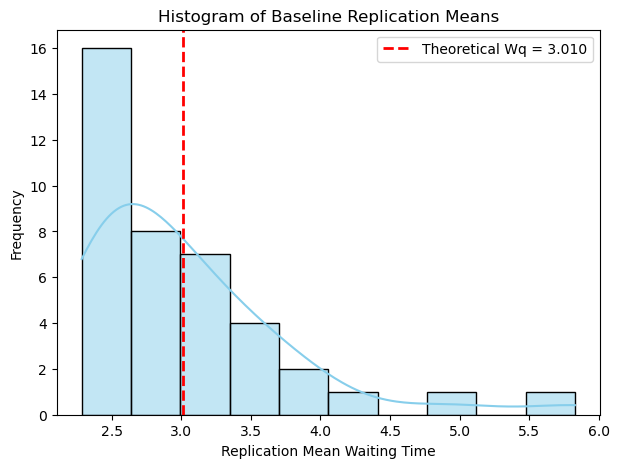

In [13]:
# hist of means
plt.figure(figsize=(7,5))
sns.histplot(sol2A, kde=True, bins=10, color="skyblue")
plt.axvline(Wq, color="red", linestyle="--", linewidth=2, 
            label=f"Theoretical Wq = {Wq:.3f}") # theoretical value

plt.xlabel("Replication Mean Waiting Time")
plt.ylabel("Frequency")
plt.title("Histogram of Baseline Replication Means")
plt.legend()
plt.show()

In [14]:
## add confidence interval
def mean_CI(data, alpha=0.05):
    """Compute mean and two-sided confidence interval using t-distribution"""
    n = len(data)
    mean = np.mean(data)
    s = np.std(data, ddof=1)
    t_crit = 1.96 # OR stats.t.ppf(1 - alpha/2, df=n-1)
    halfwidth = t_crit * s / np.sqrt(n)
    return mean - halfwidth, mean + halfwidth

In [15]:
# H0: Wq = Wq_sim, H1: Wq_sim != Wq
# Get confidence intervals and t-value = (Wq_sim - Wq) / (sigma_Wqsim/np.sqrt(n_runs))
alpha = 0.05
CI_low, CI_high = mean_CI(sol2A)
t_stat, p_value = stats.ttest_1samp(sol2A, Wq)

print(f"95% CI: [{CI_low:.4f}, {CI_high:.4f}] minutes")
print(f"Validation t-test: t={t_stat:.3f}, p={p_value:.4f}") 
if p_value < alpha:
    print("We reject null hypothesis: Wq != Wq_sim. Our simulation is ill conditioned")
else:
    print("We fail to reject null hypothesis: Wq = Wq_sim. Our simulation is well performed")

95% CI: [2.7870, 3.2440] minutes
Validation t-test: t=0.044, p=0.9655
We fail to reject null hypothesis: Wq = Wq_sim. Our simulation is well performed


In [16]:
# 2B: compare scenarios
lambda_arrival = sept_mean / (30*16*50*60)
print(f"Arrival rate: {lambda_arrival:.2f} passengers/minute")
# Baseline: current operations
num_servers_baseline = 1 
sigma_baseline = 0.25
E_B_baseline = 1
rho_baseline = lambda_arrival * E_B_baseline / num_servers_baseline
print(f"Baseline utilization: {rho_baseline:.2f}")

# Option A: add additional server
num_servers_A = 2 
sigma_A = 0.25
E_B_A = 1
rho_A = lambda_arrival * E_B_A/ num_servers_A
print(f"Case A utilization: {rho_A:.2f}")

# Option B: reduce variability of service time
num_servers_B = 1
sigma_B = 0.1
E_B_B = 1
rho_B = lambda_arrival * E_B_B/ num_servers_B
print(f"Case B utilization: {rho_B:.2f}")

# Option C

Arrival rate: 4.23 passengers/minute
Baseline utilization: 4.23
Case A utilization: 2.12
Case B utilization: 4.23


In [17]:
sol2B_baseline, _ = run_simulations(n_runs = 40, arrival_rate=lambda_arrival,
                                service_mean= E_B_baseline,
                                service_stdev = sigma_baseline,
                                num_passengers= 3000, 
                                warm_up = 0,
                                num_servers= num_servers_baseline)
Wq_baseline = np.mean(sol2B_baseline)
sigma_Wqbaseline = np.std(sol2B_baseline, ddof = 1)

In [18]:
sol2B_A, _ = run_simulations(n_runs = 40, arrival_rate=lambda_arrival,
                                service_mean= E_B_A,
                                service_stdev = sigma_A,
                                num_passengers= 3000, 
                                warm_up = 0,
                                num_servers= num_servers_A)
Wq_A = np.mean(sol2B_A)
sigma_WqA = np.std(sol2B_A, ddof = 1)

In [19]:
sol2B_B, _ = run_simulations(n_runs = 40, arrival_rate=lambda_arrival,
                                service_mean= E_B_B,
                                service_stdev = sigma_B,
                                num_passengers= 3000, 
                                warm_up = 0,
                                num_servers= num_servers_B)
Wq_B = np.mean(sol2B_B)
sigma_WqB = np.std(sol2B_B, ddof = 1)

In [20]:
## Compute Cs for scenarios with one server (var B / mean B**2) 
## Not reported in main code (since unstable?)
C_s_squared_baseline = (sigma_baseline**2) / (E_B_baseline**2) 
E_W_baseline = (rho_baseline / (1 - rho_baseline)) * E_B_baseline * (1 + C_s_squared_baseline) / 2
C_s_squared_B = (sigma_B**2) / (E_B_B**2)
E_W_B = (rho_B / (1 - rho_B)) * E_B_B * (1 + C_s_squared_B) / 2
print(C_s_squared_baseline, C_s_squared_B)

0.0625 0.010000000000000002


In [21]:
# Model a dynamic staffing system
class DynamicLaneSimulator:
    """
    Option C: dynamic staffing with up to `max_servers` lanes.
    Start with `initial_servers`; open extra lanes when total queue length is large.
    """
    def __init__(self, arrival_rate,
                 service_mean, service_stdev,
                 num_passengers,
                 initial_servers=1, max_servers=2,
                 queue_threshold=50,
                 warmup=1000,
                 seed=42):

        self.arrival_rate   = arrival_rate
        self.service_mean   = service_mean
        self.service_stdev  = service_stdev
        self.num_passengers = num_passengers

        self.initial_servers = initial_servers
        self.max_servers     = max_servers
        self.queue_threshold = queue_threshold
        self.warmup          = warmup

        self.rng = np.random.default_rng(seed)
        self.wait_times = []

        self.env = simpy.Environment()

        # one Resource per potential lane
        self.servers = [simpy.Resource(self.env, capacity=1)
                        for _ in range(max_servers)]
        self.active_servers = initial_servers

    def generate_service(self):
        return max(0, self.rng.normal(self.service_mean, self.service_stdev))

    def total_queue_length(self):
        return sum(len(s.queue) for s in self.servers[:self.active_servers])

    def choose_server(self):
        # open new lane if queues are long and we have spare lanes
        if (self.total_queue_length() >= self.queue_threshold and
                self.active_servers < self.max_servers):
            self.active_servers += 1

        active = self.servers[:self.active_servers]
        return min(active, key=lambda s: len(s.queue))

    def passenger(self, pid):
        arrival_time = self.env.now

        server = self.choose_server()
        with server.request() as req:
            yield req
            start_service = self.env.now
            if pid >= self.warmup:
                self.wait_times.append(start_service - arrival_time)
            yield self.env.timeout(self.generate_service())

    def arrival_process(self):
        for i in range(self.num_passengers):
            self.env.process(self.passenger(i))
            interarrival = self.rng.exponential(1 / self.arrival_rate)
            yield self.env.timeout(interarrival)

    def run(self):
        self.env.process(self.arrival_process())
        self.env.run()
        return np.array(self.wait_times)


def run_simulations_dynamic_C(R=40, base_seed=2000):
    means = []

    for r in range(R):
        sim = DynamicLaneSimulator(
            arrival_rate=lambda_arrival,  # same λ as baseline/A/B
            service_mean=1.0,
            service_stdev=0.25,
            num_passengers=3000,          
            initial_servers=1,
            max_servers=2,
            queue_threshold=50,
            warmup=0,
            seed=base_seed + r
        )
        waits = sim.run()
        if len(waits) > 0:
            means.append(waits.mean())

    return np.array(means)

sol2B_C = run_simulations_dynamic_C()
Wq_C = np.mean(sol2B_C)
sigma_WqC = np.std(sol2B_C, ddof = 1)

print("Mean Wq (dynamic):", Wq_C)
print("SD of Wq (dynamic):", sigma_WqC)


Mean Wq (dynamic): 401.15819373050937
SD of Wq (dynamic): 7.933249928393679


In [22]:
class DynamicLaneSimulatorFast:
    """
    Option C: dynamic staffing with up to `max_servers` lanes.
    Faster version: no separate controller process, we only
    check the queue and update active_servers on arrivals.
    """
    def __init__(self, arrival_rate,
                 service_mean, service_stdev,
                 num_passengers,
                 initial_servers=1, max_servers=2,
                 queue_threshold=50,
                 seed=42):

        self.arrival_rate   = arrival_rate
        self.service_mean   = service_mean
        self.service_stdev  = service_stdev
        self.num_passengers = num_passengers

        self.initial_servers = initial_servers
        self.max_servers     = max_servers
        self.queue_threshold = queue_threshold

        self.rng = np.random.default_rng(seed)
        self.wait_times = []

        self.env = simpy.Environment()

        # one Resource per potential lane
        self.servers = [simpy.Resource(self.env, capacity=1)
                        for _ in range(max_servers)]
        self.active_servers = initial_servers

        # for avg active servers
        self._last_time = 0.0
        self._area_S = 0.0
        self.avg_active_servers = None

    def generate_service(self):
        return max(0, self.rng.normal(self.service_mean, self.service_stdev))

    def total_queue_length(self):
        return sum(len(s.queue) for s in self.servers[:self.active_servers])

    def _update_area(self):
        """Accumulate S(t)*dt since last event."""
        now = self.env.now
        dt = now - self._last_time
        if dt > 0:
            self._area_S += self.active_servers * dt
            self._last_time = now

    def _maybe_add_server(self):
        """Called on arrivals: update area, then maybe open a lane."""
        self._update_area()
        q_len = self.total_queue_length()
        if q_len >= self.queue_threshold and self.active_servers < self.max_servers:
            self.active_servers += 1

    def choose_server(self):
        active = self.servers[:self.active_servers]
        return min(active, key=lambda s: len(s.queue))
    

    def passenger(self, pid):
        arrival_time = self.env.now

        # When someone arrives, first possibly add server
        self._maybe_add_server()

        server = self.choose_server()
        with server.request() as req:
            yield req
            start_service = self.env.now
            self.wait_times.append(start_service - arrival_time)
            yield self.env.timeout(self.generate_service())

    def arrival_process(self):
        for i in range(self.num_passengers):
            self.env.process(self.passenger(i))
            interarrival = self.rng.exponential(1 / self.arrival_rate)
            yield self.env.timeout(interarrival)

    def run(self):
        self.env.process(self.arrival_process())
        self.env.run()

        # final area update
        self._update_area()
        total_time = self.env.now
        self.avg_active_servers = self._area_S / total_time

        return np.array(self.wait_times)


In [23]:
def run_dynamic_C_fast(R=40, base_seed=2000):
    means = []
    avg_servers = []

    for r in range(R):
        sim = DynamicLaneSimulatorFast(
            arrival_rate=lambda_arrival,
            service_mean=1.0,
            service_stdev=0.25,
            num_passengers=3000,  
            initial_servers=1,
            max_servers=2,
            queue_threshold=50,
            seed=base_seed + r
        )
        waits = sim.run()
        means.append(waits.mean())
        avg_servers.append(sim.avg_active_servers)

    return np.array(means), np.array(avg_servers)

sol2B_C, dynamic_avg_servers = run_dynamic_C_fast()

Wq_C = np.mean(sol2B_C)
sigma_WqC = np.std(sol2B_C, ddof = 1)

Avg_Server = np.mean(dynamic_avg_servers)

print("Mean Wq (dynamic):", Wq_C)
print("SD of Wq (dynamic):", sigma_WqC)
print("Average servers:", Avg_Server)


Mean Wq (dynamic): 401.15819373050937
SD of Wq (dynamic): 7.933249928393679
Average servers: 1.989158426412225


In [24]:
print(f"Baseline (1 server, sd = 0.25) - Mean {Wq_baseline}, sd = {sigma_Wqbaseline}")
print(f"Option A(More server) (2 server, sd = 0.25) - Mean {Wq_A}, sd = {sigma_WqA}")
print(f"Option B(Lower Variance) (1 server, sd = 0.10) - Mean {Wq_B}, sd = {sigma_WqB}" )
print(f"Option C(Dynamic Staffing) (1 server, sd = 0.25) - Mean {Wq_C}, sd = {sigma_WqC}")

Baseline (1 server, sd = 0.25) - Mean 1142.3736533708598, sd = 11.189911395889986
Option A(More server) (2 server, sd = 0.25) - Mean 394.1716343595541, sd = 7.483177320405853
Option B(Lower Variance) (1 server, sd = 0.10) - Mean 1142.9911069396856, sd = 9.36793128936417
Option C(Dynamic Staffing) (1 server, sd = 0.25) - Mean 401.15819373050937, sd = 7.933249928393679


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

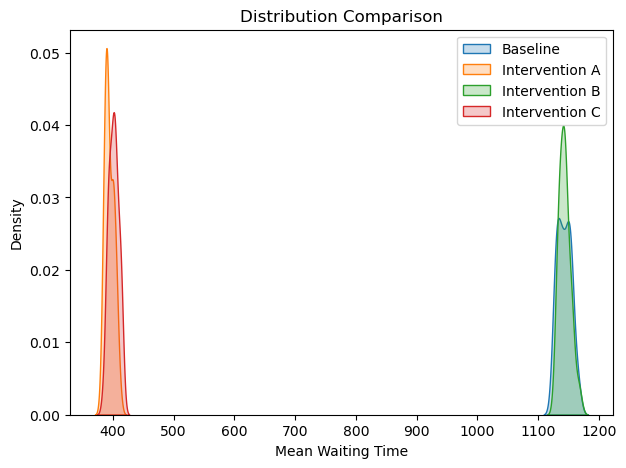

In [25]:
plt.figure(figsize=(7,5))
sns.kdeplot(sol2B_baseline, fill=True, label="Baseline")
sns.kdeplot(sol2B_A, fill=True, label="Intervention A")
sns.kdeplot(sol2B_B, fill=True, label="Intervention B")
sns.kdeplot(sol2B_C, fill=True, label="Intervention C")

plt.xlabel("Mean Waiting Time")
plt.ylabel("Density")
plt.title("Distribution Comparison")
plt.legend()
plt.show()


In [26]:
alpha = 0.05
# Are option A or B statistically different from baseline?
# H0: Wq_baseline = Wq_A or Wq_B, H1: Wq_baseline != Wq_A or Wq_B
# Welch's test (ttest_ind)
# Compare baseline with A/B
t_statA, p_valueA = stats.ttest_ind(sol2B_A, sol2B_baseline, equal_var=False, alternative="less") # to make it one-sided
t_statB, p_valueB = stats.ttest_ind(sol2B_B, sol2B_baseline, equal_var=False, alternative="less")
t_statC, p_valueC = stats.ttest_ind(sol2B_C, sol2B_baseline, equal_var=False, alternative="less")
# Compare A and B: are they different
t_statAB, p_valueAB = stats.ttest_ind(sol2B_A, sol2B_B, equal_var=False, alternative="less")
t_statAC, p_valueAC = stats.ttest_ind(sol2B_C, sol2B_A, equal_var=False, alternative="less")
t_statBC, p_valueBC = stats.ttest_ind(sol2B_C, sol2B_B, equal_var=False, alternative="less")
# CIs
CI_base_low, CI_base_high = mean_CI(sol2B_baseline, alpha)
CI_A_low, CI_A_high = mean_CI(sol2B_A, alpha)
CI_B_low, CI_B_high = mean_CI(sol2B_B, alpha)
CI_C_low, CI_C_high = mean_CI(sol2B_C, alpha)

# Print P-values and interpret
print(f"Baseline CI: [{CI_base_low:.4f}, {CI_base_high:.4f}] for Wq ={Wq_baseline:.3f}")
print(f"Option A CI: [{CI_A_low:.4f}, {CI_A_high:.4f}] for Wq= {Wq_A:.3f}")
print(f"Option B CI: [{CI_B_low:.4f}, {CI_B_high:.4f}] for Wq= {Wq_B:.3f}")
print(f"Option C CI: [{CI_C_low:.4f}, {CI_C_high:.4f}] for Wq= {Wq_C:.3f}")

# P-value interpretation (assuming p-values already computed)
print(f"P-value (Option A vs Baseline): {p_valueA:.6f}")
if p_valueA < alpha:
    print("Significant difference")
else:
    print("Not significant")

print(f"P-value (Option B vs Baseline): {p_valueB:.6f}")
if p_valueB < alpha:
    print("Significant difference")
else:
    print("Not significant")

print(f"P-value (Option C vs Baseline): {p_valueC:.6f}")
if p_valueC < alpha:
    print("Significant difference")
else:
    print("Not significant")

print(f"P-value (Option A vs Option B): {p_valueAB:.6f}")
if p_valueAB < alpha:
    print("Option A and B differ")
else:
    print("No significant difference")

print(f"P-value (Option A vs Option C): {p_valueAC:.6f}")
if p_valueAC < alpha:
    print("Option A and C differ")
else:
    print("No significant difference")

print(f"P-value (Option B vs Option C): {p_valueBC:.6f}")
if p_valueBC < alpha:
    print("Option B and C differ")
else:
    print("No significant difference")


Baseline CI: [1138.9059, 1145.8414] for Wq =1142.374
Option A CI: [391.8526, 396.4907] for Wq= 394.172
Option B CI: [1140.0880, 1145.8943] for Wq= 1142.991
Option C CI: [398.6997, 403.6167] for Wq= 401.158
P-value (Option A vs Baseline): 0.000000
Significant difference
P-value (Option B vs Baseline): 0.605129
Not significant
P-value (Option C vs Baseline): 0.000000
Significant difference
P-value (Option A vs Option B): 0.000000
Option A and B differ
P-value (Option A vs Option C): 0.999940
No significant difference
P-value (Option B vs Option C): 0.000000
Option B and C differ


In [27]:
# Evaluate actual effect size 
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    sx2 = np.var(x, ddof=1)
    sy2 = np.var(y, ddof=1)

    welch_sd = np.sqrt((sx2 +sy2) / 2)
    return (np.mean(x) - np.mean(y)) / welch_sd

In [28]:
d_A = cohens_d(sol2B_baseline, sol2B_A)
d_B = cohens_d(sol2B_baseline, sol2B_B)
d_C = cohens_d(sol2B_baseline, sol2B_C)
d_AC = cohens_d(sol2B_A, sol2B_C)
d_AB = cohens_d(sol2B_A, sol2B_B)
d_BC = cohens_d(sol2B_B, sol2B_C)

print("Effect size (A vs baseline):", d_A)
print("Effect size (B vs baseline):", d_B)
print("Effect size (C vs baseline):", d_C)
print("Effect size (A vs C):", d_AC)
print("Effect size (B vs C):", d_BC)
print("Effect size (A vs B):", d_AB)

Effect size (A vs baseline): 78.60321777693228
Effect size (B vs baseline): -0.05983534365225693
Effect size (C vs baseline): 76.41994061050292
Effect size (A vs C): -0.9059925237149675
Effect size (B vs C): 85.4618448490777
Effect size (A vs B): -88.32405860188632


In [29]:
# Table for the statistics
rows = [
    {
        "comparison": "Baseline vs A",
        "group1": "Baseline",
        "group2": "Option A",
        "mean1": Wq_baseline,
        "CI1_low": CI_base_low,
        "CI1_high": CI_base_high,
        "mean2": Wq_A,
        "CI2_low": CI_A_low,
        "CI2_high": CI_A_high,
        "t_stat": t_statA,
        "p_value": p_valueA,
        "cohens_d": d_A,
    },
    {
        "comparison": "Baseline vs B",
        "group1": "Baseline",
        "group2": "Option B",
        "mean1": Wq_baseline,
        "CI1_low": CI_base_low,
        "CI1_high": CI_base_high,
        "mean2": Wq_B,
        "CI2_low": CI_B_low,
        "CI2_high": CI_B_high,
        "t_stat": t_statB,
        "p_value": p_valueB,
        "cohens_d": d_B,
    },
    {
        "comparison": "Baseline vs C",
        "group1": "Baseline",
        "group2": "Option C",
        "mean1": Wq_baseline,
        "CI1_low": CI_base_low,
        "CI1_high": CI_base_high,
        "mean2": Wq_C,
        "CI2_low": CI_C_low,
        "CI2_high": CI_C_high,
        "t_stat": t_statC,
        "p_value": p_valueC,
        "cohens_d": d_C,
    },
    {
        "comparison": "A vs B",
        "group1": "Option A",
        "group2": "Option B",
        "mean1": Wq_A,
        "CI1_low": CI_A_low,
        "CI1_high": CI_A_high,
        "mean2": Wq_B,
        "CI2_low": CI_B_low,
        "CI2_high": CI_B_high,
        "t_stat": t_statAB,
        "p_value": p_valueAB,
        "cohens_d": d_AB,
    },
    {
        "comparison": "A vs C",
        "group1": "Option A",
        "group2": "Option C",
        "mean1": Wq_A,
        "CI1_low": CI_A_low,
        "CI1_high": CI_A_high,
        "mean2": Wq_C,
        "CI2_low": CI_C_low,
        "CI2_high": CI_C_high,
        "t_stat": t_statAC,
        "p_value": p_valueAC,
        "cohens_d": d_AC,
    },
    {
        "comparison": "B vs C",
        "group1": "Option B",
        "group2": "Option C",
        "mean1": Wq_B,
        "CI1_low": CI_B_low,
        "CI1_high": CI_B_high,
        "mean2": Wq_C,
        "CI2_low": CI_C_low,
        "CI2_high": CI_C_high,
        "t_stat": t_statBC,
        "p_value": p_valueBC,
        "cohens_d": d_BC,
    },
]

stats_df = pd.DataFrame(rows)
stats_df_rounded = stats_df.round({
    "mean1": 3, "mean2": 3,
    "CI1_low": 3, "CI1_high": 3,
    "CI2_low": 3, "CI2_high": 3,
    "t_stat": 3, "p_value": 6, "cohens_d": 3,
})

print(stats_df_rounded)


      comparison    group1    group2     mean1   CI1_low  CI1_high     mean2  \
0  Baseline vs A  Baseline  Option A  1142.374  1138.906  1145.841   394.172   
1  Baseline vs B  Baseline  Option B  1142.374  1138.906  1145.841  1142.991   
2  Baseline vs C  Baseline  Option C  1142.374  1138.906  1145.841   401.158   
3         A vs B  Option A  Option B   394.172   391.853   396.491  1142.991   
4         A vs C  Option A  Option C   394.172   391.853   396.491   401.158   
5         B vs C  Option B  Option C  1142.991  1140.088  1145.894   401.158   

    CI2_low  CI2_high   t_stat   p_value  cohens_d  
0   391.853   396.491 -351.524  0.000000    78.603  
1  1140.088  1145.894    0.268  0.605129    -0.060  
2   398.700   403.617 -341.760  0.000000    76.420  
3  1140.088  1145.894 -394.997  0.000000   -88.324  
4   398.700   403.617    4.052  0.999940    -0.906  
5   398.700   403.617 -382.197  0.000000    85.462  


In [30]:
print(stats_df_rounded.to_latex(index=False))

\begin{tabular}{lllrrrrrrrrr}
\toprule
comparison & group1 & group2 & mean1 & CI1_low & CI1_high & mean2 & CI2_low & CI2_high & t_stat & p_value & cohens_d \\
\midrule
Baseline vs A & Baseline & Option A & 1142.374000 & 1138.906000 & 1145.841000 & 394.172000 & 391.853000 & 396.491000 & -351.524000 & 0.000000 & 78.603000 \\
Baseline vs B & Baseline & Option B & 1142.374000 & 1138.906000 & 1145.841000 & 1142.991000 & 1140.088000 & 1145.894000 & 0.268000 & 0.605129 & -0.060000 \\
Baseline vs C & Baseline & Option C & 1142.374000 & 1138.906000 & 1145.841000 & 401.158000 & 398.700000 & 403.617000 & -341.760000 & 0.000000 & 76.420000 \\
A vs B & Option A & Option B & 394.172000 & 391.853000 & 396.491000 & 1142.991000 & 1140.088000 & 1145.894000 & -394.997000 & 0.000000 & -88.324000 \\
A vs C & Option A & Option C & 394.172000 & 391.853000 & 396.491000 & 401.158000 & 398.700000 & 403.617000 & 4.052000 & 0.999940 & -0.906000 \\
B vs C & Option B & Option C & 1142.991000 & 1140.088000 & 1145.89

In [31]:
# Explore the trade-off between the efficiency and resource usage
def run_dynamic_grid(thresholds, max_servers_list,
                     R=20,
                     base_seed=5000,
                     num_passengers=3000):
    """
    Explore trade-off between queue threshold and max_servers.
    Returns a list of dicts: one per (threshold, max_servers) setting.
    """
    results = []

    for S_max in max_servers_list:
        for Q in thresholds:
            mean_waits = []
            avg_servers = []

            for r in range(R):
                sim = DynamicLaneSimulatorFast(
                    arrival_rate=lambda_arrival,
                    service_mean=1.0,
                    service_stdev=0.25,
                    num_passengers=num_passengers,
                    initial_servers=1,
                    max_servers=S_max,
                    queue_threshold=Q,
                    seed=base_seed + r
                )
                waits = sim.run()
                mean_waits.append(waits.mean())
                avg_servers.append(sim.avg_active_servers)

            results.append({
                "Q_thr": Q,
                "max_servers": S_max,
                "mean_Wq": np.mean(mean_waits),
                "sd_Wq": np.std(mean_waits, ddof=1),
                "avg_active_servers": np.mean(avg_servers)
            })

    return results

In [32]:
thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
max_servers_list = [2, 3, 4, 5, 6, 7, 8, 9]

results = run_dynamic_grid(thresholds, max_servers_list, R=20, num_passengers=3000)

for res in results:
    print(
        f"max={res['max_servers']}, Q={res['Q_thr']:3d} | "
        f"mean_Wq={res['mean_Wq']:.3f}, sd={res['sd_Wq']:.3f}, "
        f"avg_servers={res['avg_active_servers']:.2f}"
    )

max=2, Q= 10 | mean_Wq=398.121, sd=8.351, avg_servers=2.00
max=2, Q= 20 | mean_Wq=399.874, sd=8.902, avg_servers=2.00
max=2, Q= 30 | mean_Wq=401.517, sd=9.085, avg_servers=1.99
max=2, Q= 40 | mean_Wq=403.410, sd=7.567, avg_servers=1.99
max=2, Q= 50 | mean_Wq=404.523, sd=8.628, avg_servers=1.99
max=2, Q= 60 | mean_Wq=405.832, sd=8.442, avg_servers=1.99
max=2, Q= 70 | mean_Wq=406.310, sd=9.819, avg_servers=1.99
max=2, Q= 80 | mean_Wq=409.587, sd=8.399, avg_servers=1.98
max=2, Q= 90 | mean_Wq=412.858, sd=9.136, avg_servers=1.98
max=2, Q=100 | mean_Wq=413.349, sd=8.982, avg_servers=1.98
max=3, Q= 10 | mean_Wq=150.281, sd=8.237, avg_servers=2.99
max=3, Q= 20 | mean_Wq=153.081, sd=7.084, avg_servers=2.99
max=3, Q= 30 | mean_Wq=154.704, sd=8.248, avg_servers=2.98
max=3, Q= 40 | mean_Wq=156.604, sd=6.982, avg_servers=2.98
max=3, Q= 50 | mean_Wq=158.904, sd=6.093, avg_servers=2.97
max=3, Q= 60 | mean_Wq=161.715, sd=9.055, avg_servers=2.96
max=3, Q= 70 | mean_Wq=163.319, sd=7.191, avg_servers=2.

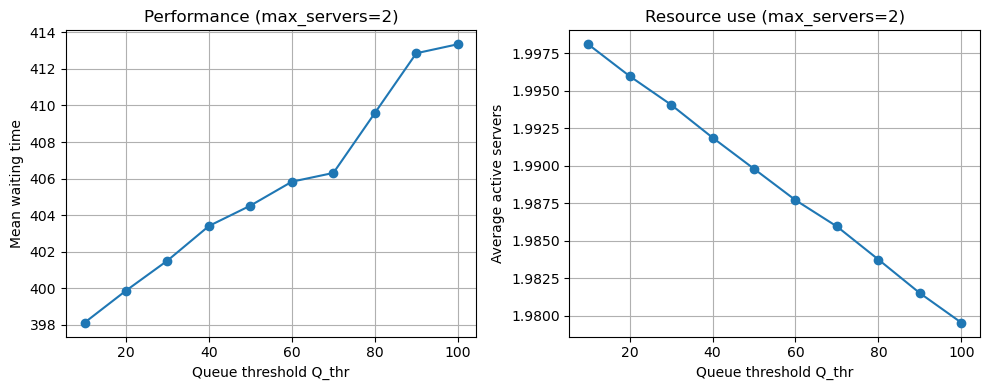

In [33]:
# Visualization
Qs = sorted({r["Q_thr"] for r in results if r["max_servers"] == 2})
mean_Wq_2 = [r["mean_Wq"] for r in results if r["max_servers"] == 2]
avg_S_2   = [r["avg_active_servers"] for r in results if r["max_servers"] == 2]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(Qs, mean_Wq_2, marker='o')
plt.xlabel("Queue threshold Q_thr")
plt.ylabel("Mean waiting time")
plt.title("Performance (max_servers=2)")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(Qs, avg_S_2, marker='o')
plt.xlabel("Queue threshold Q_thr")
plt.ylabel("Average active servers")
plt.title("Resource use (max_servers=2)")
plt.grid(True)


plt.tight_layout()
plt.show()


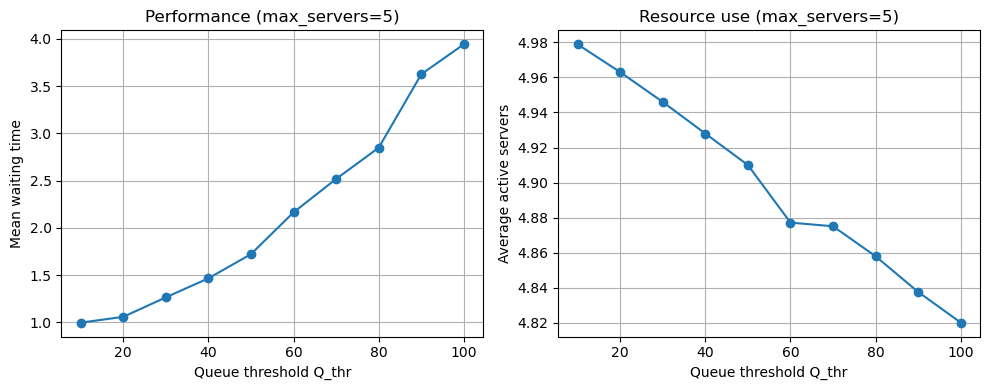

In [34]:
# Visualization
Qs = sorted({r["Q_thr"] for r in results if r["max_servers"] == 5})
mean_Wq_5 = [r["mean_Wq"] for r in results if r["max_servers"] == 5]
avg_S_5   = [r["avg_active_servers"] for r in results if r["max_servers"] == 5]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(Qs, mean_Wq_5, marker='o')
plt.xlabel("Queue threshold Q_thr")
plt.ylabel("Mean waiting time")
plt.title("Performance (max_servers=5)")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(Qs, avg_S_5, marker='o')
plt.xlabel("Queue threshold Q_thr")
plt.ylabel("Average active servers")
plt.title("Resource use (max_servers=5)")
plt.grid(True)


plt.tight_layout()
plt.show()


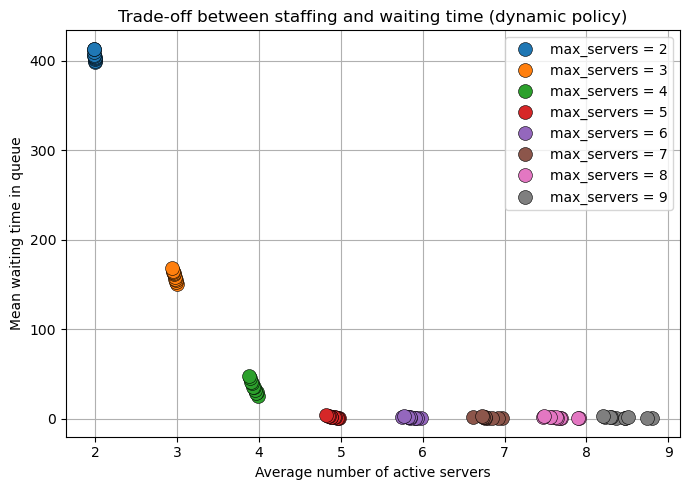

In [35]:
# thresholds and max_servers_list used in the grid
thresholds = sorted({r["Q_thr"] for r in results})
max_servers_list = sorted({r["max_servers"] for r in results})

plt.figure(figsize=(7,5))

for S_max in max_servers_list:
    xs = [r["avg_active_servers"] for r in results if r["max_servers"] == S_max]
    ys = [r["mean_Wq"] for r in results if r["max_servers"] == S_max]
    Qs = [r["Q_thr"] for r in results if r["max_servers"] == S_max]

    # plot “frontier” for this max_servers value
    plt.plot(xs, ys, 'o', label=f"max_servers = {S_max}", markersize = 10, markeredgecolor='black', markeredgewidth = 0.4)


plt.xlabel("Average number of active servers")
plt.ylabel("Mean waiting time in queue")
plt.title("Trade-off between staffing and waiting time (dynamic policy)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
